# Alpha Tuning
Exploring how the loop sensitivity (`alpha`) affects reservoir performance.

**alpha** = how strongly the input warps each whirlpool's spin.
- Small alpha → loops barely respond to input → flat, boring reservoir
- Large alpha → loops react wildly → potentially chaotic, noisy
- Sweet spot → rich nonlinear response without chaos

Currently alpha is drawn from N(0, 1). We test different spreads (standard deviations):
- **Narrow**: N(0, 0.1) — very small sensitivity
- **Medium**: N(0, 0.5) — moderate
- **Original**: N(0, 1.0) — paper default
- **Wide**: N(0, 2.0) — high sensitivity
- **Very wide**: N(0, 5.0) — aggressive

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Utility functions

In [2]:
def ridge_regression(X_train, y_train, X_test, beta=1e-6):
    I = np.eye(X_train.shape[1])
    W = np.linalg.solve(X_train.T @ X_train + beta * I, X_train.T @ y_train)
    return X_test @ W, W


def generate_narma10(u):
    T = len(u)
    y = np.zeros(T)
    for t in range(10, T - 1):
        y[t + 1] = (
            0.3 * y[t]
            + 0.05 * y[t] * np.sum(y[t - 9:t + 1])
            + 1.5 * u[t - 9] * u[t]
            + 0.1
        )
    return y


def memory_capacity(u, X, delays, washout=500, train_len=2500, test_len=2000):
    mc = []
    for d in delays:
        X_train = X[washout + d : washout + train_len]
        y_train = u[washout : washout + train_len - d]
        X_test  = X[washout + train_len : washout + train_len + test_len]
        y_test  = u[washout + train_len - d : washout + train_len + test_len - d]
        y_pred, _ = ridge_regression(X_train, y_train, X_test)
        corr  = np.corrcoef(y_pred.ravel(), y_test.ravel())[0, 1]
        mc.append(0.0 if np.isnan(corr) else corr**2)
    return np.array(mc)


def narma10_nmse(u, X, washout=500, train_len=2500, test_len=2000):
    y       = generate_narma10(u)
    X_train = X[washout : washout + train_len]
    y_train = y[washout : washout + train_len]
    X_test  = X[washout + train_len : washout + train_len + test_len]
    y_test  = y[washout + train_len : washout + train_len + test_len]
    _, Wout     = ridge_regression(X_train, y_train, X_train)
    y_pred_test = X_test @ Wout
    return np.mean((y_pred_test - y_test)**2) / np.var(y_test)

## Fixed reservoir with tunable alpha spread

In [3]:
def simulate_reservoir(T=6000, N=500, M=20, dt=1.0, seed=7, alpha_std=1.0):
    """Fixed reservoir (delta-s) with tunable alpha standard deviation."""
    rng   = np.random.default_rng(seed)
    u     = rng.uniform(0.0, 0.5, size=T)
    A     = rng.uniform(0.5, 1.5, size=N)
    alpha = rng.normal(0.0, alpha_std, size=N)
    tau   = rng.integers(1, 16, size=N).astype(float)
    lam   = np.exp(-dt / tau)
    phi   = rng.uniform(0, 2 * np.pi, size=N)
    Wmix  = rng.normal(0.0, 1.0 / np.sqrt(N), size=(M, N))

    s = np.zeros(N)
    R = np.zeros((T, M))
    for t in range(T):
        s_prev  = s.copy()
        s       = lam * s + (1.0 - lam) * u[t]
        delta_s = s - s_prev
        phi     = phi + alpha * delta_s * dt
        g       = A * np.cos(phi)
        R[t, :] = Wmix @ g
    return u, R

## Run alpha tuning experiment

In [4]:
delays = np.arange(1, 41)

configs = [
    {"label": "Narrow  (std=0.1)", "alpha_std": 0.1},
    {"label": "Medium  (std=0.5)", "alpha_std": 0.5},
    {"label": "Original(std=1.0)", "alpha_std": 1.0},
    {"label": "Wide    (std=2.0)", "alpha_std": 2.0},
    {"label": "V.Wide  (std=5.0)", "alpha_std": 5.0},
]

results = []
for cfg in configs:
    u, R = simulate_reservoir(alpha_std=cfg["alpha_std"])
    X    = np.hstack([R, np.ones((R.shape[0], 1))])
    mc   = memory_capacity(u, X, delays)
    nmse = narma10_nmse(u, X)
    results.append({"label": cfg["label"], "mc": mc, "nmse": nmse})
    print(f"{cfg['label']}  |  Total MC = {mc.sum():.2f}  |  NARMA10 NMSE = {nmse:.4f}")

Narrow  (std=0.1)  |  Total MC = 4.25  |  NARMA10 NMSE = 0.3179
Medium  (std=0.5)  |  Total MC = 4.82  |  NARMA10 NMSE = 0.2987
Original(std=1.0)  |  Total MC = 4.86  |  NARMA10 NMSE = 0.2982
Wide    (std=2.0)  |  Total MC = 4.78  |  NARMA10 NMSE = 0.3008
V.Wide  (std=5.0)  |  Total MC = 4.00  |  NARMA10 NMSE = 0.3158


## Plot results

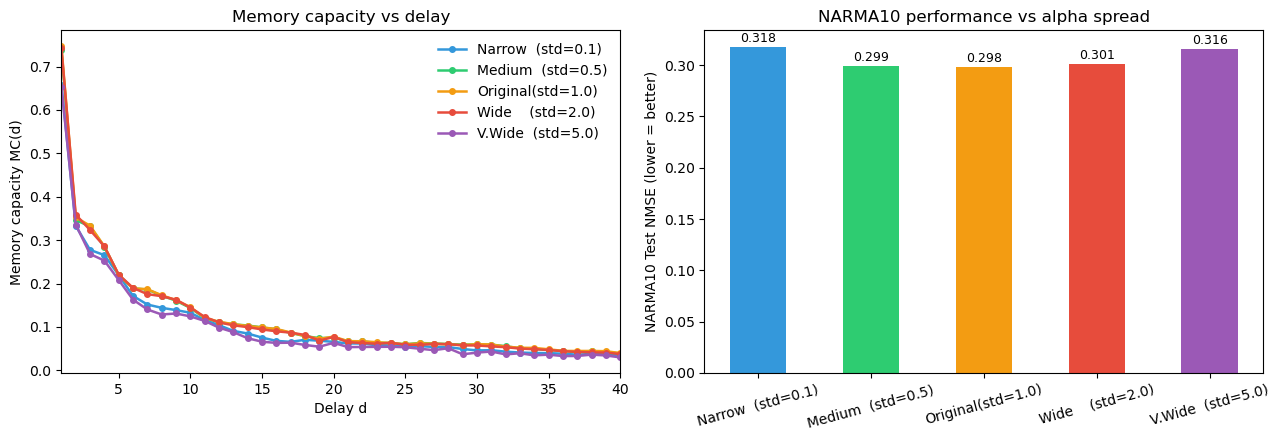

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"]

# --- Left: memory capacity curves ---
for res, color in zip(results, colors):
    axes[0].plot(delays, res["mc"], 'o-', lw=1.8, ms=4, color=color, label=res["label"])

axes[0].set_xlabel("Delay d")
axes[0].set_ylabel("Memory capacity MC(d)")
axes[0].set_title("Memory capacity vs delay")
axes[0].set_xlim(delays.min(), delays.max())
axes[0].legend(frameon=False)

# --- Right: NARMA10 NMSE bar chart ---
labels = [r["label"] for r in results]
nmses  = [r["nmse"] for r in results]
bars   = axes[1].bar(labels, nmses, color=colors, width=0.5)
axes[1].set_ylabel("NARMA10 Test NMSE (lower = better)")
axes[1].set_title("NARMA10 performance vs alpha spread")
axes[1].tick_params(axis='x', labelrotation=15)
for bar, val in zip(bars, nmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.3f}",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("alpha_tuning.png", dpi=300, bbox_inches="tight")
plt.show()